# Pneumonia X-Ray Classification — ResNet50 Fine-Tuning
### Fixed & Optimized for ≥95% Accuracy


In [1]:
# ── If running on Kaggle ──────────────────────────────────────────
import kagglehub
paultimothymooney_chest_xray_pneumonia_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')
print('Data source import complete.')

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Data source import complete.


In [2]:
import numpy as np
import pandas as pd
import os, math
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Input
from tensorflow.keras.regularizers import l2

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)
import tensorflow.keras.backend as K
import warnings
warnings.filterwarnings('ignore')

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU: []


In [3]:
base_path = '/kaggle/input/chest-xray-pneumonia/chest_xray'
train_dir = f'{base_path}/train'
val_dir   = f'{base_path}/val'
test_dir  = f'{base_path}/test'

## EDA & Class Balance Check

In [4]:
def check_class_balance(path):
    class_counts = {}
    print(f'Checking balance for: {path}\n')
    class_names = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    print('Class Counts:')
    for class_name in class_names:
        count = len(os.listdir(os.path.join(path, class_name)))
        class_counts[class_name] = count
        print(f'  {class_name}: {count} images')
    counts = list(class_counts.values())
    if max(counts) > min(counts) * 2:
        print('\n⚠ Dataset is IMBALANCED — class_weight will compensate.')
    else:
        print('\n✓ Dataset is relatively balanced.')
    return class_counts

train_counts = check_class_balance(train_dir)
print('\n' + '='*40 + '\n')
check_class_balance(test_dir)

Checking balance for: /kaggle/input/chest-xray-pneumonia/chest_xray/train

Class Counts:
  PNEUMONIA: 3875 images
  NORMAL: 1341 images

⚠ Dataset is IMBALANCED — class_weight will compensate.


Checking balance for: /kaggle/input/chest-xray-pneumonia/chest_xray/test

Class Counts:
  PNEUMONIA: 390 images
  NORMAL: 234 images

✓ Dataset is relatively balanced.


{'PNEUMONIA': 390, 'NORMAL': 234}

In [ ]:

from sklearn.utils.class_weight import compute_class_weight

normal_count    = train_counts.get('NORMAL', 1341)
pneumonia_count = train_counts.get('PNEUMONIA', 3875)
total           = normal_count + pneumonia_count

w_normal    = total / (2 * normal_count)
w_pneumonia = total / (2 * pneumonia_count)
class_weight_dict = {0: w_normal, 1: w_pneumonia}
print('Computed class weights:', class_weight_dict)

Computed class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


## Data Preprocessing & Augmentation

In [ ]:

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32


train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=False, 
    brightness_range=[0.9, 1.1],
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True,
    seed=42
)


val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=42
)


test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print('Class indices:', train_generator.class_indices)  

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


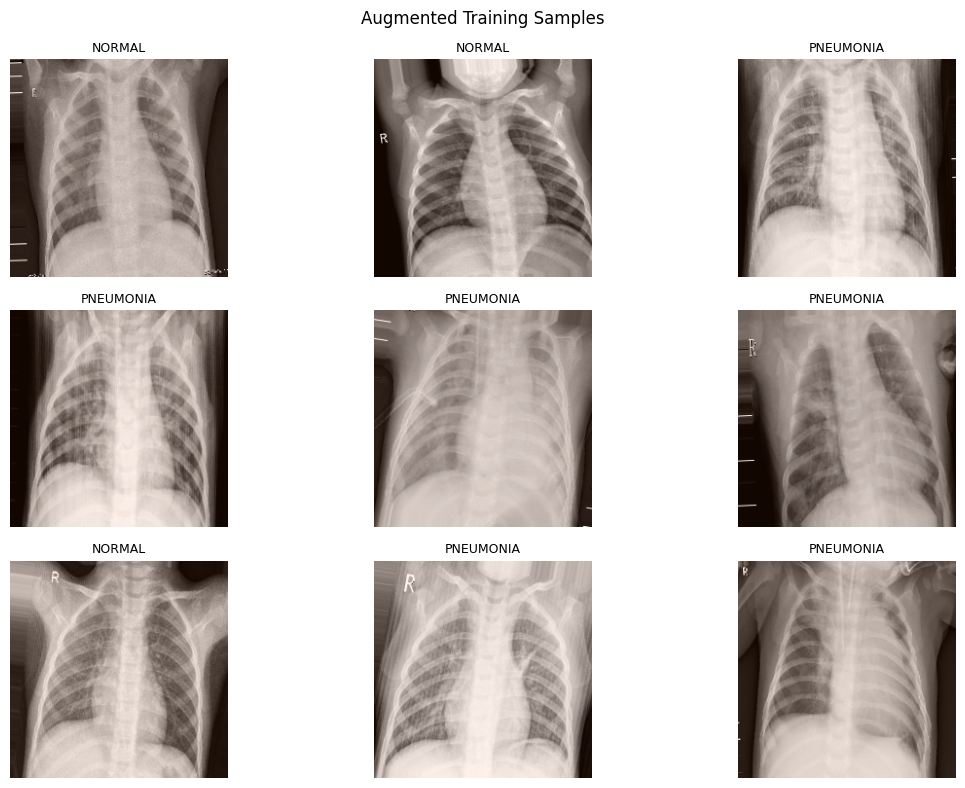

In [ ]:

def deprocess_image(x):
    x = x.copy()
    x -= x.min()
    x /= (x.max() + 1e-8)
    return x

x_batch, y_batch = next(train_generator)
plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(deprocess_image(x_batch[i]))
    label = 'PNEUMONIA' if y_batch[i] == 1 else 'NORMAL'
    plt.title(label, fontsize=9)
    plt.axis('off')
plt.suptitle('Augmented Training Samples')
plt.tight_layout()
plt.show()

## Build Model — Phase 1 (Frozen Base)

In [ ]:

def create_model():
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    inputs = Input(shape=(224, 224, 3))
    x = base_model(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    return model, base_model

model, base_model = create_model()
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,121,729 (92.02 MB)

 Trainable params: 529,409 (2.02 MB)

 Non-trainable params: 23,592,320 (90.00 MB)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=3e-4),   
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [10]:
# ── Mount Drive (Colab only) ──
from google.colab import drive
drive.mount('/content/drive')
SAVE_PATH = '/content/drive/MyDrive/best_model_pneumonia.keras'

Mounted at /content/drive


In [ ]:

callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, mode='max', verbose=1),
    ModelCheckpoint(SAVE_PATH, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.3, patience=3, min_lr=1e-7, mode='max', verbose=1)
]

steps_per_epoch  = math.ceil(train_generator.samples / BATCH_SIZE)
validation_steps = math.ceil(val_generator.samples / BATCH_SIZE)


history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=20,
    validation_data=val_generator,
    validation_steps=validation_steps,
    callbacks=callbacks_phase1,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8492 - auc: 0.9516 - loss: 0.7610 - precision: 0.9814 - recall: 0.8151
Epoch 1: val_accuracy improved from None to 0.83126, saving model to /content/drive/MyDrive/best_model_pneumonia.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_model_pneumonia.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 1231s 9s/step - accuracy: 0.8982 - auc: 0.9790 - loss: 0.6635 - precision: 0.9887 - recall: 0.8729 - val_accuracy: 0.8313 - val_auc: 0.9918 - val_loss: 0.8789 - val_precision: 1.0000 - val_recall: 0.7729 - learning_rate: 3.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9482 - auc: 0.9892 - loss: 0.5488 - precision: 0.9902 - recall: 0.9393
Epoch 2: val_accuracy improved from 0.83126 to 0.89454, saving model to /content/drive/MyDrive/best_model_pneumonia.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_model_pneumonia.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 1204s 9s/step - accuracy: 0

## Fine-Tuning — Phase 2 (Unfreeze Last 50 Layers)

In [ ]:

model = load_model(SAVE_PATH)
base_model = model.get_layer('resnet50')
base_model.trainable = True
for layer in base_model.layers[:-80]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False


model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')]
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, mode='max', verbose=1),
    ModelCheckpoint(SAVE_PATH, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.3, patience=3, min_lr=1e-8, mode='max', verbose=1)
]

history_fine = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=callbacks_phase2,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.9639 - auc: 0.9941 - loss: 0.4236 - precision: 0.9926 - recall: 0.9581 
Epoch 1: val_accuracy improved from None to 0.92809, saving model to /content/drive/MyDrive/best_model_pneumonia.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_model_pneumonia.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 2153s 16s/step - accuracy: 0.9653 - auc: 0.9938 - loss: 0.4239 - precision: 0.9914 - recall: 0.9616 - val_accuracy: 0.9281 - val_auc: 0.9958 - val_loss: 0.5372 - val_precision: 1.0000 - val_recall: 0.9032 - learning_rate: 1.0000e-05
Epoch 2/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.9755 - auc: 0.9966 - loss: 0.4002 - precision: 0.9907 - recall: 0.9756 
Epoch 2: val_accuracy improved from 0.92809 to 0.93864, saving model to /content/drive/MyDrive/best_model_pneumonia.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_model_pneumonia.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 2192s 17s/step - accur

## Training Curves

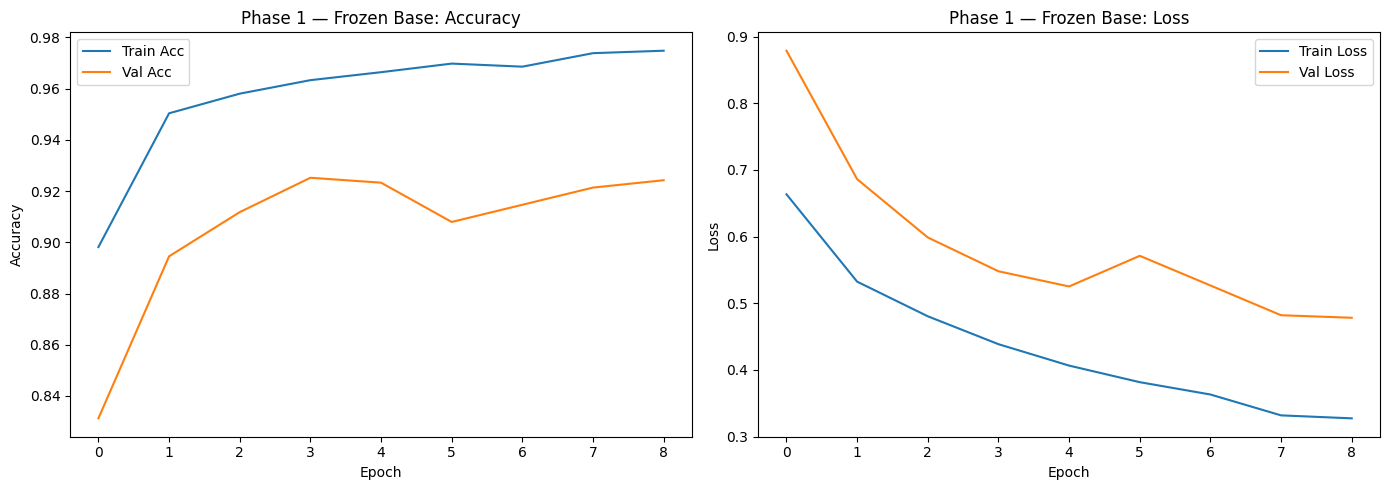

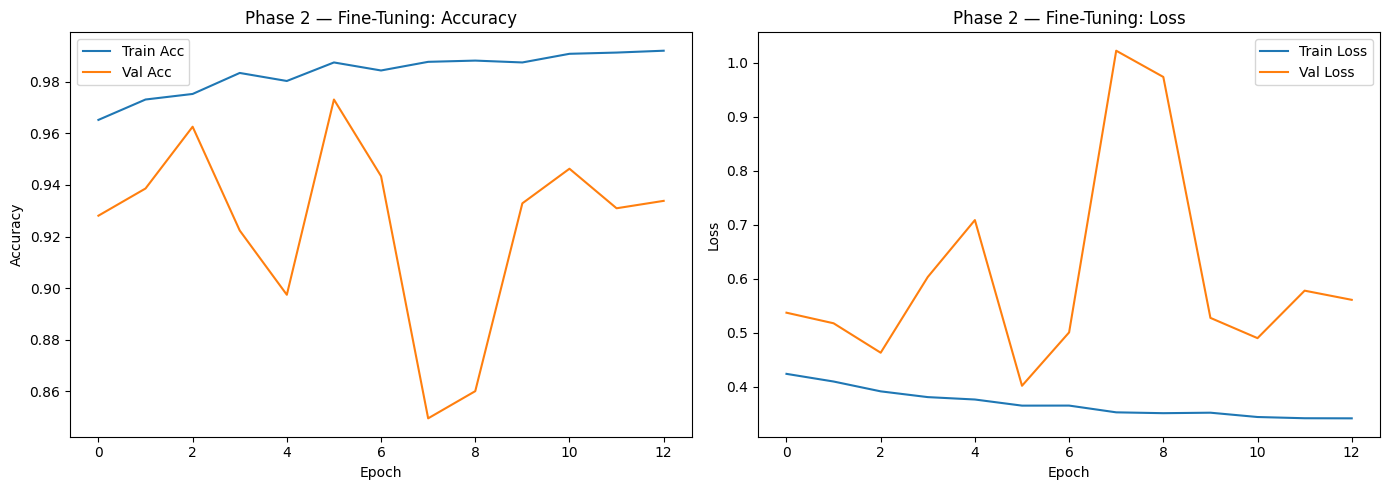

In [13]:
def plot_history(hist, title_prefix=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(hist.history['accuracy'],     label='Train Acc')
    axes[0].plot(hist.history['val_accuracy'], label='Val Acc')
    axes[0].set_title(f'{title_prefix} Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(hist.history['loss'],     label='Train Loss')
    axes[1].plot(hist.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title_prefix} Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout(); plt.show()

plot_history(history,      'Phase 1 — Frozen Base:')
plot_history(history_fine, 'Phase 2 — Fine-Tuning:')

## Model Evaluation on Test Set

In [14]:
# Load best saved model
model = load_model(SAVE_PATH)

test_generator.reset()
y_probs = model.predict(test_generator, verbose=1).ravel()
y_true  = test_generator.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 142s 7s/step


In [ ]:

thresholds = np.arange(0.1, 0.9, 0.01)
rows = []
for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    rows.append([
        t,
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0)
    ])

df_thresh = pd.DataFrame(rows, columns=['threshold','accuracy','precision','recall','f1'])
best_row  = df_thresh.loc[df_thresh['f1'].idxmax()]
best_threshold = best_row['threshold']
print('Best threshold (by F1):', best_threshold)
print(best_row)

Best threshold (by F1): 0.8899999999999996
threshold    0.890000
accuracy     0.937500
precision    0.933333
recall       0.969231
f1           0.950943
Name: 79, dtype: float64


In [16]:
y_pred = (y_probs >= best_threshold).astype(int)

print('\n=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

print('Accuracy :', accuracy_score(y_true, y_pred))
print('Precision:', precision_score(y_true, y_pred))
print('Recall   :', recall_score(y_true, y_pred))
print('F1 Score :', f1_score(y_true, y_pred))
print('ROC-AUC  :', roc_auc_score(y_true, y_probs))


=== Classification Report ===
              precision    recall  f1-score   support

      NORMAL       0.95      0.88      0.91       234
   PNEUMONIA       0.93      0.97      0.95       390

    accuracy                           0.94       624
   macro avg       0.94      0.93      0.93       624
weighted avg       0.94      0.94      0.94       624

Accuracy : 0.9375
Precision: 0.9333333333333333
Recall   : 0.9692307692307692
F1 Score : 0.9509433962264151
ROC-AUC  : 0.9718496603111987


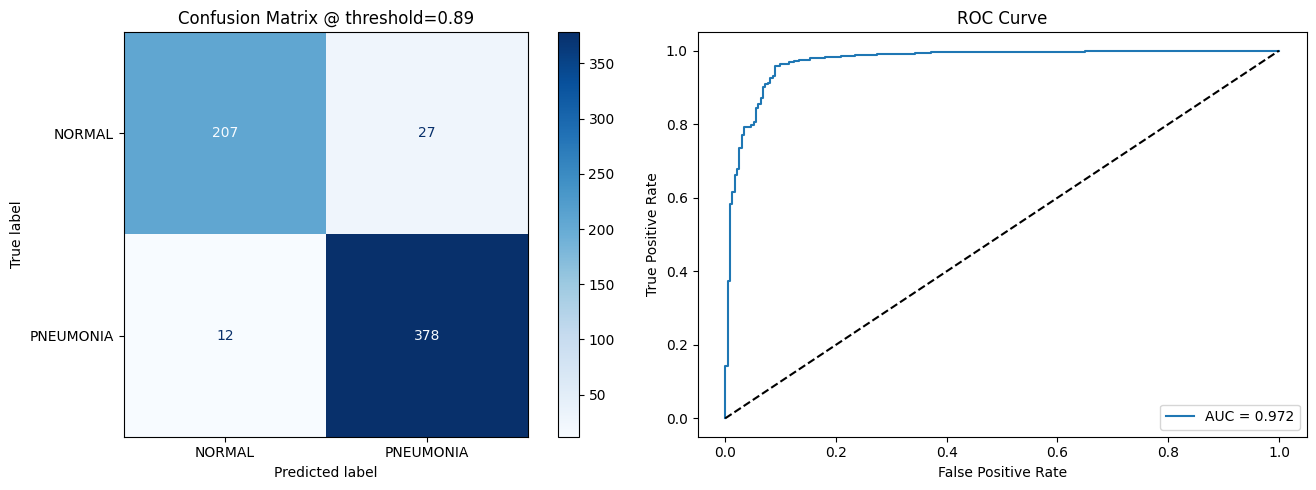

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['NORMAL','PNEUMONIA']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Confusion Matrix @ threshold={best_threshold:.2f}')

# ROC Curve
auc_score = roc_auc_score(y_true, y_probs)
fpr, tpr, _ = roc_curve(y_true, y_probs)
axes[1].plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## Misclassified Samples

Misclassified: 39 / 624


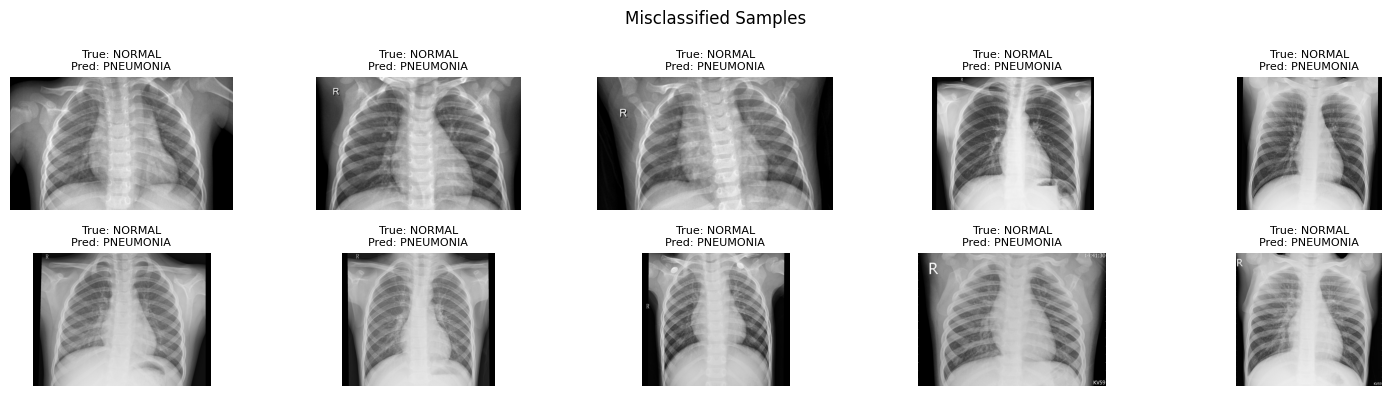

In [18]:
errors = np.where(y_pred != y_true)[0]
print(f'Misclassified: {len(errors)} / {len(y_true)}')
idx_to_class = {0: 'NORMAL', 1: 'PNEUMONIA'}

n_show = min(10, len(errors))
plt.figure(figsize=(15, 4))
for i, err_idx in enumerate(errors[:n_show]):
    img_path = os.path.join(test_dir, test_generator.filenames[err_idx])
    img = Image.open(img_path).convert('RGB')
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"True: {idx_to_class[y_true[err_idx]]}\nPred: {idx_to_class[y_pred[err_idx]]}", fontsize=8)
plt.suptitle('Misclassified Samples')
plt.tight_layout()
plt.show()

## Grad-CAM Visualisation

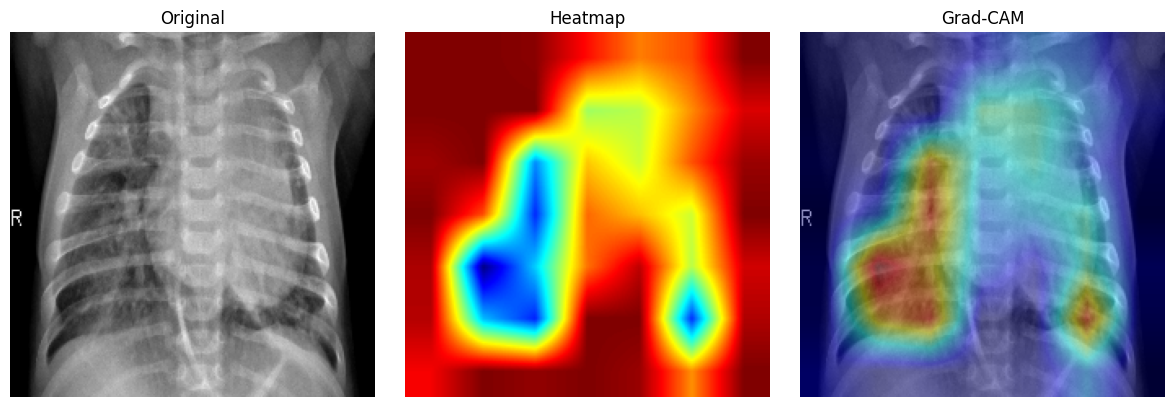

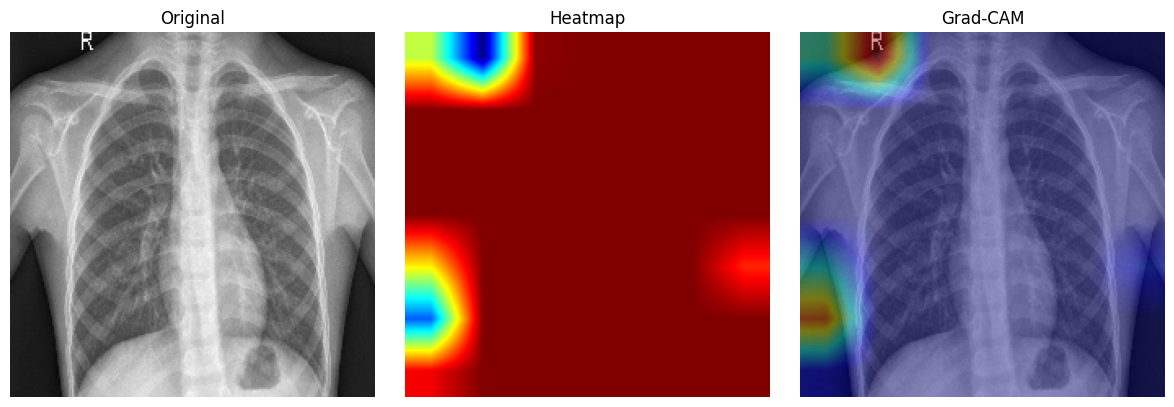

In [19]:
def get_gradcam_heatmap(img_array, model, last_conv_layer_name='conv5_block3_out'):
    base_model     = model.get_layer('resnet50')
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[last_conv_layer.output, base_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, base_output = grad_model(img_array)
        x = base_output
        for layer in model.layers[2:]:
            x = layer(x)
        loss = x[:, 0]

    grads       = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap      = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def show_gradcam(img_path, model):
    img       = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    heatmap   = get_gradcam_heatmap(img_array, model)
    heatmap   = cv2.resize(heatmap, (224, 224))
    heatmap   = np.uint8(255 * heatmap)
    heatmap   = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    original  = cv2.imread(img_path)
    original  = cv2.resize(original, (224, 224))
    superimposed = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB)); plt.title('Original'); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(heatmap);                                    plt.title('Heatmap');  plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)); plt.title('Grad-CAM'); plt.axis('off')
    plt.tight_layout(); plt.show()


# Show Grad-CAM for one PNEUMONIA and one NORMAL sample
for label in ['PNEUMONIA', 'NORMAL']:
    for f in test_generator.filenames:
        if label in f:
            show_gradcam(os.path.join(test_dir, f), model)
            break